Load Healthy Models

In [2]:
import torch
from pathlib import Path
import joblib
# prefix = Path("generate_plots.ipynb").resolve().parent

path_prefix ="synthetic_experiments_dif_hp/healthy/trained_models/unscaled/"
## create a function to load the model from the given string path
def load_model(model_path):

    model = torch.load(model_path)
    return model

models = {}
## loop through differen encoding folders to load the models per type
for enc_size in [2, 4, 8, 16]:
    for model_type in ["pca", "ae_basic", "ae_layered"]:
        if model_type == "pca":
            model_path = f"{path_prefix}{model_type}/enc_{enc_size}/model.joblib"
            model = joblib.load(model_path)
            print(f"Loaded {model_type} with encoding size {enc_size} from {model_path}")
        else:
            model_path = f"{path_prefix}{model_type}/enc_{enc_size}/model.pt"
            model = load_model(model_path)
            print(f"Loaded {model_type} with encoding size {enc_size} from {model_path}")
    models[enc_size] = {model_type: model for model_type in ["pca", "ae_basic", "ae_layered"]}


Loaded pca with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_2/model.joblib
Loaded ae_basic with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_2/model.pt
Loaded ae_layered with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_2/model.pt
Loaded pca with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_4/model.joblib
Loaded ae_basic with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_4/model.pt
Loaded ae_layered with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_4/model.pt
Loaded pca with encoding size 8 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_8/model.joblib
Loaded ae_basic with encoding size 8 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_8/mod

c:\Users\saris\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


LOAD PCA HEALTHY MODEL

In [3]:
pca_healthy = {enc_size: models[enc_size]["pca"] for enc_size in models}
ae_basic_healthy = {enc_size: models[enc_size]["ae_basic"] for enc_size in models}
ae_layered_healthy = {enc_size: models[enc_size]["ae_layered"] for enc_size in models}
# print(pca_healthy)

LOAD TRAIN/VALIDATION VALUES FOR HEALTHY MODELS

In [4]:
import json
def load_history(model_history_path, is_pca=False):
    with open(model_history_path, 'r') as f:
        history_file = json.load(f)
    if is_pca:
        train_loss = history_file["train_mse"]
        val_loss = history_file["val_mse"]
        test_mse = history_file["test_mse"]
        return train_loss, val_loss, test_mse
    train_loss = history_file["train"]
    val_loss = history_file["val"]
    return train_loss, val_loss, None

In [5]:

## will hold the history for all models, with keys as (enc_size, model_type) and values as the history, which is a map in itself with keys train_mse, val_mse
history_map = {}
for enc_size in [2, 4, 8, 16]:
    for model_type in ["pca", "ae_basic", "ae_layered"]:
        if model_type == "pca":
            model_history_path = f"{path_prefix}{model_type}/enc_{enc_size}/results.json"
            history = load_history(model_history_path, is_pca=True)
            print(f"Loaded history for {model_type} with encoding size {enc_size} from {model_history_path}")
        else:
            model_history_path = f"{path_prefix}{model_type}/enc_{enc_size}/history.json"
            history = load_history(model_history_path)
            print(f"Loaded history for {model_type} with encoding size {enc_size} from {model_history_path}")

        history_map[(enc_size, model_type)] = {"train_curve_loss": history[0], "val_curve_loss": history[1]}

        ## if test mse is not None, add it to the history map
        if history[2] is not None:
            history_map[(enc_size, model_type)]["test_mse"] = history[2]

Loaded history for pca with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_2/results.json
Loaded history for ae_basic with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_2/history.json
Loaded history for ae_layered with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_2/history.json
Loaded history for pca with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_4/results.json
Loaded history for ae_basic with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_4/history.json
Loaded history for ae_layered with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_4/history.json
Loaded history for pca with encoding size 8 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_8/results.json
Loaded history for ae

CREATE TRAIN/VALIDATION LOSS CURVE GRAPH, CHOSEN ENC, 6 LINES, 2 PER MODEL TYPE


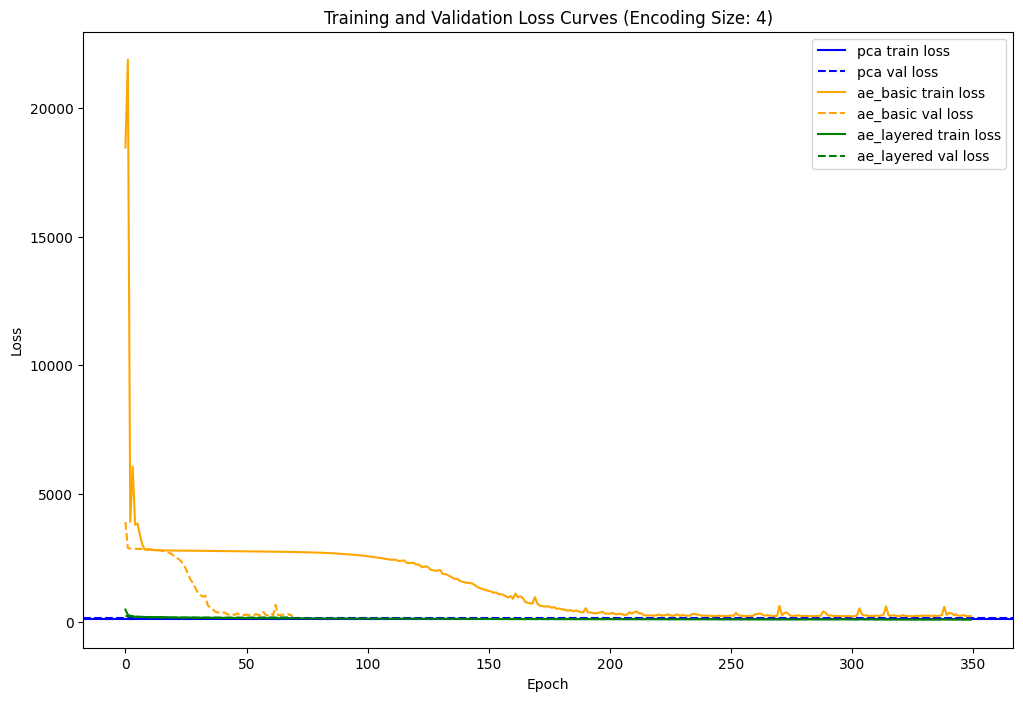

In [6]:
import matplotlib.pyplot as plt
import numpy as np
##color map for the different models
color_map = {"pca": "blue", "ae_basic": "orange", "ae_layered": "green"}
##plot train as solid, val as dashed
## plotting train val loss curves of the models for a certain encoding size
plt.figure(figsize=(12, 8))
enc = 4
for model_type in ["pca", "ae_basic", "ae_layered"]:
    history = history_map[(enc, model_type)]
    train_curve = history['train_curve_loss']
    eval_curve = history['val_curve_loss']
    if model_type == 'pca' and not isinstance(train_curve, list):
        plt.axhline(train_curve, label=f"{model_type} train loss", color=color_map[model_type])
        plt.axhline(eval_curve, label=f"{model_type} val loss", color=color_map[model_type], linestyle="--")
        continue
    plt.plot(train_curve, label=f"{model_type} train loss", color=color_map[model_type])
    plt.plot(eval_curve, label=f"{model_type} val loss", color=color_map[model_type], linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training and Validation Loss Curves (Encoding Size: {enc})")
plt.legend()
plt.show()
plt.close()

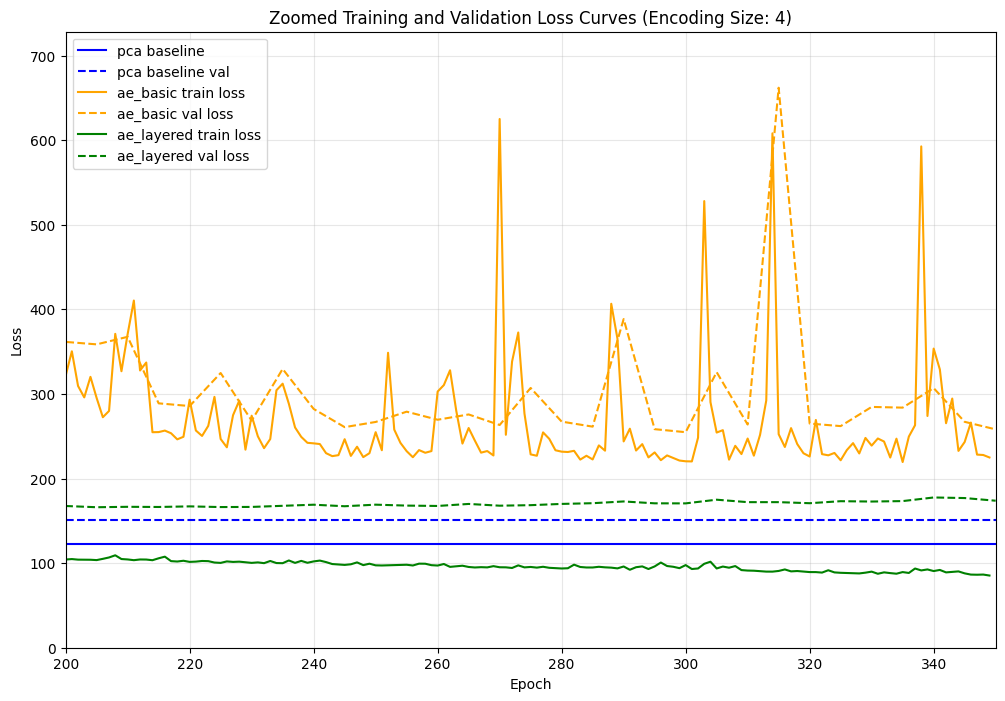

In [7]:
## Same code, but now with zoom on last 100 epochs, according to two best models
plt.figure(figsize=(12, 8))
enc = 4
start_x = 200
y_max = 0 # Track global max for the y-axis limit

for model_type in ["pca", "ae_basic", "ae_layered"]:
    history = history_map[(enc, model_type)]
    train_curve = history['train_curve_loss']
    eval_curve = history['val_curve_loss']
    
    
    if model_type == 'pca':
        pca_train = train_curve[0] if isinstance(train_curve, list) else train_curve
        pca_eval = eval_curve[0] if isinstance(eval_curve, list) else eval_curve
        plt.axhline(y=pca_train, label=f"{model_type} baseline", color=color_map[model_type])
        plt.axhline(y=pca_eval, label=f"{model_type} baseline val", color=color_map[model_type], linestyle="--")
        # Only update y_max if PCA is the highest value in the window
        y_max = max(y_max, pca_train * 1.1)
        continue # Skip the epoch logic below entirely for PCA
        
    
    plt.plot(train_curve, label=f"{model_type} train loss", color=color_map[model_type])
    
    epoch_jump = len(train_curve) // len(eval_curve) if len(eval_curve) > 0 else 1
    eval_epochs = np.arange(epoch_jump, len(train_curve) + 1, epoch_jump)
    eval_epochs = eval_epochs[:len(eval_curve)]
    plt.plot(eval_epochs, eval_curve, label=f"{model_type} val loss", color=color_map[model_type], linestyle="--")

    
    zoomed_train = train_curve[start_x:]
                            
    # Grab only the eval data in the zoomed window
    eval_start_idx = start_x // epoch_jump
    zoomed_eval = eval_curve[eval_start_idx:] if len(eval_curve) > 0 else [0]
                            
    max_train = max(zoomed_train) if zoomed_train else 0
    max_eval = max(zoomed_eval) if zoomed_eval else 0
    local_max = max(max_train, max_eval)
                            
    # Conditionally update the global y_max instead of overwriting it
    if local_max * 1.1 > y_max:
        y_max = local_max * 1.1

plt.xlim(start_x, len(train_curve))
plt.ylim(0, y_max)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Zoomed Training and Validation Loss Curves (Encoding Size: {enc})")
plt.legend()
plt.grid(True, alpha=0.3) 

plt.show()
plt.close()

In [8]:
import torch
from pathlib import Path
import joblib
# prefix = Path("generate_plots.ipynb").resolve().parent

path_prefix ="synthetic_experiments_dif_hp/healthy/trained_models/unscaled/"
## create a function to load the model from the given string path
def load_model(model_path):

    model = torch.load(model_path)
    return model

models = {}
## loop through differen encoding folders to load the models per type
for enc_size in [2, 4, 8, 16]:
    for model_type in ["pca", "ae_basic", "ae_layered"]:
        if model_type == "pca":
            model_path = f"{path_prefix}{model_type}/enc_{enc_size}/model.joblib"
            model = joblib.load(model_path)
            print(f"Loaded {model_type} with encoding size {enc_size} from {model_path}")
        else:
            model_path = f"{path_prefix}{model_type}/enc_{enc_size}/model.pt"
            model = load_model(model_path)
            print(f"Loaded {model_type} with encoding size {enc_size} from {model_path}")
    models[enc_size] = {model_type: model for model_type in ["pca", "ae_basic", "ae_layered"]}


Loaded pca with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_2/model.joblib
Loaded ae_basic with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_2/model.pt
Loaded ae_layered with encoding size 2 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_2/model.pt
Loaded pca with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_4/model.joblib
Loaded ae_basic with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_4/model.pt
Loaded ae_layered with encoding size 4 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_layered/enc_4/model.pt
Loaded pca with encoding size 8 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/pca/enc_8/model.joblib
Loaded ae_basic with encoding size 8 from synthetic_experiments_dif_hp/healthy/trained_models/unscaled/ae_basic/enc_8/mod

c:\Users\saris\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


BOXPLOTS FOR TEST MSE RESULTS

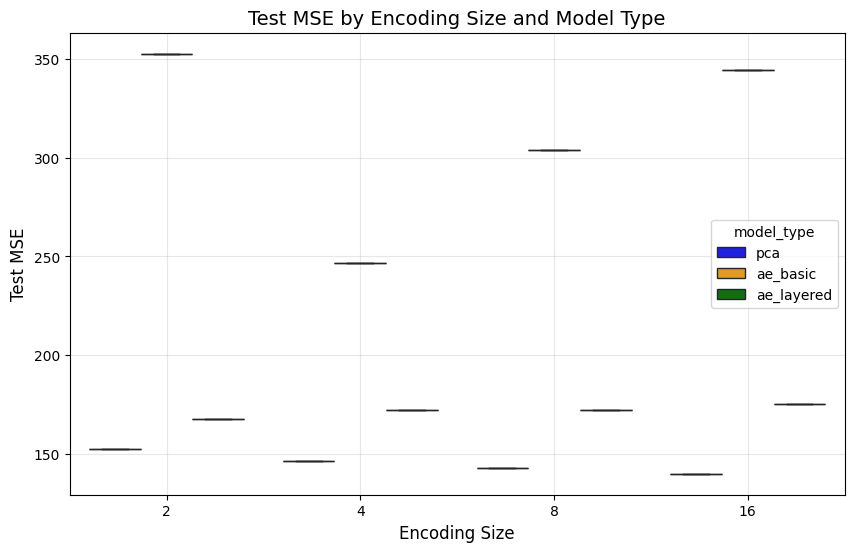

In [9]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path_prefix = "synthetic_experiments_dif_hp/healthy/trained_models/unscaled/"
color_map = {"pca": "blue", "ae_basic": "orange", "ae_layered": "green"}

# 1. Collect the data
data_records = []

for enc_size in [2, 4, 8, 16]:
    for model_type in ["pca", "ae_basic", "ae_layered"]:
        mse_value = None
        
        # Determine the correct file path based on model type
        if model_type == "pca":
            filepath = f"{path_prefix}{model_type}/enc_{enc_size}/results.json"
        else:
            filepath = f"{path_prefix}{model_type}/enc_{enc_size}/best_meta.json"
            
        # Read the file and extract test_mse
        try:
            with open(filepath, 'r') as f:
                file_content = json.load(f)
                
                # Check for test_mse key (adjust if your autoencoder key is slightly different!)
                if "test_mse" in file_content:
                    mse_value = file_content["test_mse"]
                else:
                    print(f"Warning: 'test_mse' not found in {filepath}")
                    
        except FileNotFoundError:
            print(f"Warning: File not found: {filepath}")
            
        # If we successfully found an MSE, add it to our records
        if mse_value is not None:
            # If you run multiple seeds/k-folds, mse_value might be a list. 
            # This handles both lists of MSEs and single float MSEs.
            if isinstance(mse_value, list):
                for val in mse_value:
                    data_records.append({"enc_size": enc_size, "model_type": model_type, "mse": val})
            else:
                data_records.append({"enc_size": enc_size, "model_type": model_type, "mse": mse_value})

# Convert to a DataFrame for easy plotting
df = pd.DataFrame(data_records)

# 2. Plotting the Box Plot
plt.figure(figsize=(10, 6))

# seaborn's boxplot automatically handles grouping by hue and x-axis
sns.boxplot(
    data=df, 
    x="enc_size", 
    y="mse", 
    hue="model_type", 
    palette=color_map
)

plt.title("Test MSE by Encoding Size and Model Type", fontsize=14)
plt.xlabel("Encoding Size", fontsize=12)
plt.ylabel("Test MSE", fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()
plt.close()

LOADING CACHE OF MIX MODEL RESULTS

loading unscaled data results for dif_hp

In [12]:
#Load pure disease 
pure_disease_csv_path = "dif_dp/pure_disease_truth.csv"
pure_disease_df = pd.read_csv(pure_disease_csv_path, index_col=0).T

print(pure_disease_df.shape)

(400, 20006)


In [17]:
file_path_unscaled = "synthetic_experiments_dif_hp/disease_mix_all/disease_mix_uniform_theta/trained_models/unscaled/eval_results_unscaled.pt"
data_bundle = torch.load(file_path_unscaled, map_location=torch.device('cpu'), weights_only=False)

cache = data_bundle["inference_cache"]
# pure_disease = data_bundle["true_disease_tensor"]
test_genes = data_bundle["test_genes_tensor"]
metadata = data_bundle["metadata"]

#Load pure disease 
pure_disease_csv_path = "dif_dp/pure_disease_truth.csv"
pure_disease_df = pd.read_csv(pure_disease_csv_path, index_col=0).T

print("Shape of pure disease df", pure_disease_df.shape)


print("Shape of test genes tensor:", test_genes.shape)
print("Metadata keys:", metadata.keys())
print("Metadata shape: ", metadata.shape)
print(metadata)
# print("Pure disease tensor shape:", pure_disease.shape)
print("Keys in bundle:", data_bundle.keys())


Shape of pure disease df (400, 20006)
Shape of test genes tensor: torch.Size([70, 20006])
Metadata keys: Index(['theta_value', 'disease_type'], dtype='object', name='GeneName')
Metadata shape:  (70, 2)
GeneName            theta_value  disease_type
DiseaseB-Sample15      0.766742           2.0
Healthy-Sample27       0.000000           0.0
Healthy-Sample170      0.000000           0.0
DiseaseA-Sample73      0.300538           1.0
DiseaseB-Sample165     0.350166           2.0
...                         ...           ...
DiseaseA-Sample113     0.197485           1.0
DiseaseB-Sample95      0.227435           2.0
Healthy-Sample242      0.000000           0.0
Healthy-Sample88       0.000000           0.0
Healthy-Sample141      0.000000           0.0

[70 rows x 2 columns]
Keys in bundle: dict_keys(['inference_cache', 'true_disease_tensor', 'test_genes_tensor', 'metadata'])


MASK TO GET DISEASE TEST SAMPLES ONLY -
NOTE: WE HAVE CURRENTLY ONLY 40 OF THOSE, MIGHT NEED TO CHANGE

In [20]:
mask = metadata.index.isin(pure_disease_df.index)
valid_disease_ids = metadata.index[mask]
print(valid_disease_ids.shape)

pure_disease_filtered = pure_disease_df.loc[valid_disease_ids]
metadata_cols = ['theta_value', 'disease_type']
pure_disease_filtered = pure_disease_filtered.drop(columns=metadata_cols, errors="ignore")
true_disease = torch.Tensor(pure_disease_filtered.values).float()
disease_mask_tensor = torch.tensor(mask)
print(f"Original test set size: {len(metadata)}")
print(f"Filtered Ground Truth Shape (Disease only): {true_disease.shape}")

(40,)
Original test set size: 70
Filtered Ground Truth Shape (Disease only): torch.Size([40, 20006])


CREATE DISEASE MSE PLOT

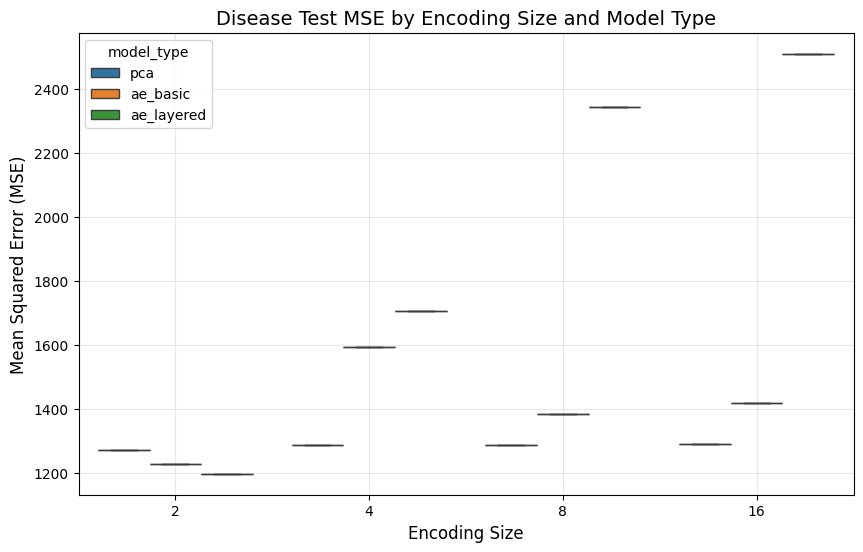

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

data_records = []

# Iterate through the dictionary
for base_name, enc_dict in cache.items():
    for enc, models_dict in enc_dict.items():
        for model_label, outputs in models_dict.items():
            
            if outputs is None:
                continue
                
            # 1. Extract the reconstructed disease tensor (Size 70)
            recon_d = outputs["disease"]
            
            # 2. ✨ Shrink predictions to match ground truth! ✨
            # Applies the True/False mask to only keep the disease patients
            recon_d_filtered = recon_d[disease_mask_tensor]
            
            # 3. Calculate the MSE 
            mse_loss = torch.nn.functional.mse_loss(recon_d_filtered, true_disease)
            
            # 4. Save to our records
            data_records.append({
                "base_name": base_name,
                "enc": enc, 
                "model_type": model_label, 
                "mse": mse_loss.item()
            })

# Convert to DataFrame
df = pd.DataFrame(data_records)

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x="enc", 
    y="mse", 
    hue="model_type", 
    # palette=color_map # Uncomment if you have color_map
)

plt.title("Disease Test MSE by Encoding Size and Model Type", fontsize=14)
plt.xlabel("Encoding Size", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()